<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/PTE_DL4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning 2026 – 4. gyakorlat
## Alulillesztés, túlillesztés és regularizáció
### Spotify-népszerűség becslése · magyarázatokkal kiegészített, egyszerű Colab-notebook

**A kérdésünk:** hogyan becsülhető egy zeneszám népszerűségi pontszáma néhány
zenei tulajdonságából, és hogyan ismerjük fel, ha a modell tanulása már nem
segít az új zeneszámok becslésében?

Ebben a gyakorlatban **regressziót** végzünk: egy számot becslünk. A cél a
`popularity`, az adatkészlet 0–100 közötti népszerűségi pontszáma. Nem műfajt
vagy „népszerű/nem népszerű” osztályt jósolunk.

A program egyszerű felépítésű marad. Egy közös függvénnyel különböző
beállítású modelleket tanítunk, megnézzük a tanulási görbéket, majd a
validáció alapján kiválasztott modellt egyszer értékeljük a teszthalmazon.

**Az óra végére tudd elmagyarázni:**

- mit jelent egy bemeneti minta és a hozzá tartozó célérték;
- mire szolgál a tanító-, a validációs és a teszthalmaz;
- mit mutat a MAE és a tanulási görbe;
- hogyan változtatja meg a tanítást az L2, a dropout és a korai leállítás;
- miért nem jelent automatikusan jobb modellt a kisebb tanítási hiba.

**Használat:** olvasd el az adott rész rövid bevezetését, majd futtasd a
kódcellát a mellette lévő futtatógombbal. Haladj fentről lefelé. Az első
alkalommal nem kell átírnod a kódot. Nem cél minden könyvtári részlet
megértése: a bemenet, a modell, a tanítás és az eredmény kapcsolatát keressük.

A 80 epochás dropout-futás is a modellválasztás **előtt** következik.
A végső teszt után ebben a kísérletben már nem módosítjuk a beállításokat.

### 1. Könyvtárak és közös beállítások

Az `import` sorok a készen rendelkezésre álló eszközöket töltik be.
Ezek nem tanítanak modellt és nem töltik le az adatokat.

| Eszköz | Mire használjuk? |
|---|---|
| `pandas`, röviden `pd` | A CSV-fájl táblázatos beolvasására és az oszlopok kiválasztására. |
| `numpy`, röviden `np` | Számtömbök, átlag, abszolút érték és medián számítására. |
| `matplotlib.pyplot`, röviden `plt` | A tanulási görbék kirajzolására. |
| TensorFlow és Keras | A neurális hálózat felépítésére és tanítására. |
| `layers` | Rétegek, például `Dense` és `Dropout` létrehozására. |
| `regularizers` | Az L2-súlybüntetés megadására. |
| `train_test_split` | A minták külön halmazokba osztására. |
| `StandardScaler` | A bemeneti jellemzők standardizálására. |

Az `os` import a feltöltött kódban szerepelt; ebben a változatban nem használjuk.
A `set_seed(42)` és a `np.random.seed(42)` a véletlenszám-generáláshoz ad
kezdőértéket. Ez segít megismételni a kísérletet, de eltérő gépeken vagy
könyvtárverziókkal nem garantál teljesen azonos eredményt.

**Futtatás után:** megjelenik a TensorFlow verziószáma. Az adatfeldolgozás
és a tanítás a későbbi cellákban történik.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow verzió:", tf.__version__)

TensorFlow verzió: 2.20.0


### 2. Az adatok beolvasása

Egy sor egy zeneszám adatait tartalmazza. A `pd.read_csv(...)` a megadott
internetes címről beolvassa a CSV-t egy `df` nevű táblázatba, amelynek
sorai és névvel ellátott oszlopai vannak.

**Ebben a változatban nem kell kézzel feltölteni a `dataset.csv` fájlt:**
a következő sor közvetlenül a kurzus adattárából tölti le. Ehhez
internetkapcsolat szükséges. A letöltés még nem tanítás.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/karsarobert/DeepLearning2026/main/dataset.csv') #spotify dataset

### 2.1. Mi lesz a bemenet, és mi lesz a cél?

A táblázat minden oszlopát nem adjuk oda a hálózatnak. A `features` lista
kilenc kiválasztott, számmal leírt tulajdonság nevét tartalmazza.

| Jellemző | Rövid értelmezés |
|---|---|
| `danceability` | Táncolhatósági jellemző. |
| `energy` | A zene intenzitását, energikusságát leíró mutató. |
| `loudness` | Hangerőjellemző. |
| `speechiness` | A beszédszerű tartalom jelenlétére utaló mutató. |
| `acousticness` | Akusztikus jellegre utaló mutató. |
| `instrumentalness` | Instrumentális jellegre utaló mutató. |
| `liveness` | Élő előadásra utaló jellemző. |
| `valence` | A zene pozitív hangulati jellegét leíró mutató. |
| `tempo` | A zene tempója. |

Egy zeneszámot tehát **kilenc bemeneti szám** képvisel. A népszerűség nem
kerülhet ezek közé: éppen azt szeretnénk a többi tulajdonságból megbecsülni.

**Mit csinálnak az előkészítő sorok?**

1. A `dropna(...)` eltávolítja azokat a sorokat, amelyekből valamelyik
   felhasznált jellemző vagy a népszerűségi pontszám hiányzik.
2. A `drop_duplicates("track_id")` ugyanazon zeneszám-azonosító első sorát
   tartja meg. Így ugyanaz a zeneszám nem kerül több példányban külön halmazokba.
3. Az `X` a kilenc bemeneti oszlop számértékeit tartalmazza.
4. Az `y` a népszerűségi célértékeket tartalmazza, 100-zal elosztva.

**Miért osztunk 100-zal?** Így például a 75 pontos népszerűség 0,75 lesz.
A feladat ettől továbbra is regresszió; a 0,75 nem egy osztály valószínűsége.
Az `astype(np.float32)` a célértékeket 32 bites lebegőpontos számként tárolja.

In [ ]:
# Jellemzők kiválasztása és tisztítás
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

df = df.dropna(subset=features + ["popularity"]).drop_duplicates("track_id")

X = df[features].values
y = (df["popularity"].values / 100.0).astype(np.float32)

### 2.2. Miért kell három külön halmaz?

Ha csak azokat a példákat mérnénk, amelyekből a hálózat tanult, nem tudnánk
megítélni, mennyire működik új zeneszámokon. Ezért a sorokat különválasztjuk.

| Halmaz | Arány | Szerep |
|---|---:|---|
| Tanító | 60% | A hálózat ezek alapján változtatja a súlyait és biasait. |
| Validációs | 20% | Ezen hasonlítjuk össze a modelleket és a beállításokat. |
| Teszt | 20% | A már meghozott végső döntés után, egyszer mérünk rajta. |

Az első `train_test_split` a minták 40%-át egy ideiglenes halmazba teszi,
így 60% marad tanításra. A második ezt a 40%-ot felezi: a teljes adathalmaz
20%-a validációs, 20%-a tesztminta lesz. A kerekítés miatt a darabszámok
nem minden adathalmazméretnél oszlanak pontosan ezekre az arányokra.

Az `X` és `y` együtt szerepel a felosztásban, ezért egy zeneszám bemenete
és célértéke nem szakad szét. A `random_state=42` rögzíti a véletlen felosztást.

**Az egyszerű felosztás értelmezése:** különböző zeneszámokat választunk szét,
de ugyanazon előadó különböző dalai kerülhetnek több halmazba is. Ez a példa
nem azt méri, hogyan teljesítünk kizárólag korábban nem látott előadók zenéin.

In [ ]:
# Adatfelosztás: 60% tanító, 20% validáció, 20% teszt
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### 2.3. Standardizálás: összehasonlítható nagyságrendű bemenetek

A tempó értéke például száz körüli lehet, miközben más jellemzők gyakran
0 és 1 közöttiek. A standardizálás oszloponként kivonja az átlagot és
eloszt a szórással:

\[
x_{\text{standard}} = \frac{x-\text{tanítási átlag}}{\text{tanítási szórás}}.
\]

**Számpélda:** ha a tanítóhalmazon egy jellemző átlaga 100, szórása 20,
akkor a 120-as értékből `(120 - 100) / 20 = 1` lesz. A 80-as értékből −1.
A negatív standardizált érték az átlagnál kisebb eredeti értéket jelent;
nem azt, hogy például a zeneszám tempója negatív lenne.

- A `fit_transform(X_train)` megtanulja a tanítóoszlopok átlagát és
  szórását, majd átalakítja a tanítóadatokat.
- A `transform(X_val)` és `transform(X_test)` **ugyanezekkel a már
  megtanult számokkal** alakítja át a másik két halmazt.

Nem számolunk új átlagot a teszthalmazból. Ezzel elkerüljük, hogy az
előfeldolgozás során a tesztadatok információja befolyásolja a tanítást.
A teszt bemeneteinek ilyen átalakítása nem tesztértékelés: a célértékeket
és a becslési hibát még nem használjuk fel.

**Figyeld meg:** a kiírt darabszámok a három halmaz méretét adják.
Az `X_train.shape[0]` a zeneszámok száma; az `X_train.shape[1]` a mintánkénti
jellemzőszám, ami ebben a feladatban 9.

In [ ]:
# Standardizálás (kizárólag a tanítóhalmazon végezzük az illesztést az adatszivárgás elkerülésére)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Tanító: {X_train.shape[0]}, Validációs: {X_val.shape[0]}, Teszt: {X_test.shape[0]}")

Tanító: 53844, Validációs: 17948, Teszt: 17949


### 3. Egy közös függvény a modellekhez

A következő függvény neve `run_experiment`, azaz „kísérlet futtatása”.
Azért használjuk, hogy ugyanazt a modellépítési és tanítási kódot ne kelljen
minden változathoz újra leírni. A híváskor megadott paraméterek mondják meg,
melyik változat készüljön el.

| Paraméter | Mit szabályoz? | Példa |
|---|---|---|
| `hidden_units` | A rejtett rétegek neuronszámai. | `[]`: nincs rejtett réteg; `[128, 64]`: két rejtett réteg. |
| `l2_rate` | Az L2-súlybüntetés erőssége. | `0.0`: nincs L2; `0.0005`: van büntetés. |
| `dropout_rate` | Egy rejtett aktiváció kiesési valószínűsége. | `0.2`: 20% kiesési valószínűség. |
| `early_stop` | Használunk-e korai leállítást. | `False` vagy `True`. |
| `epochs` | A tanítóhalmazon végzett áthaladások felső száma. | Alapértéke 40. |

**Két vizsgált alaparchitektúra:**

| Beállítás | A hálózat felépítése |
|---|---|
| `[]` | 9 bemenet → 1 lineáris kimenet |
| `[128, 64]` | 9 bemenet → 128 ReLU-neuron → 64 ReLU-neuron → 1 lineáris kimenet |

A lineáris modellnek is vannak tanulható súlyai és biasa, de nincs rejtett
rétege. A nagyobb hálózat a ReLU-rétegekkel nemlineáris összefüggéseket is
megtanulhat. Ettől még nem garantált, hogy az új adatokon jobb lesz.

A függvény cellájának futtatása **csak definiálja** a függvényt.
Tanítás majd akkor indul, amikor a következő szakaszban meghívjuk.

In [ ]:
def run_experiment(hidden_units, l2_rate=0.0, dropout_rate=0.0, early_stop=False, epochs=40):
    model = keras.Sequential([layers.Input(shape=(X_train.shape[1],))])
    for units in hidden_units:
        reg = regularizers.l2(l2_rate) if l2_rate > 0 else None
        model.add(layers.Dense(units, activation="relu", kernel_regularizer=reg))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1))

    model.compile(optimizer="adam", loss="mae", metrics=["mae"])

    callbacks = []
    if early_stop:
        callbacks.append(keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=6, restore_best_weights=True
        ))

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=256,
        callbacks=callbacks,
        verbose=0
    )
    return model, history

### 3.1. A modellépítés olvasása, lépésről lépésre

**`keras.Sequential(...)`** egymás után kapcsolt rétegekből épít modellt.
A `layers.Input(shape=(X_train.shape[1],))` megmondja, hogy egy minta
9 bemeneti értéket tartalmaz. Ez nem a tanítóminták számát jelenti.

**`for units in hidden_units:`** végigmegy a megadott neuronszámokon.
`[128, 64]` esetén előbb egy 128-as, majd egy 64-es réteg kerül a modellbe.
Üres listánál a ciklus egyszer sem fut le, ezért nem lesz rejtett réteg.

**`Dense(units, activation="relu", ...)`** teljesen összekötött réteget ad hozzá.
Minden neuron a bemeneteinek súlyozott összegét és egy biast használ.
A ReLU a negatív súlyozott összeget nullára változtatja, a pozitívat továbbadja.

**A két `if` feltétel** kapcsolja be az L2-t és a dropoutot. Nulla érték
mellett ezek nem aktívak. Ha a dropout bekapcsol, a ciklus minden rejtett
Dense-réteg után elhelyez egy Dropout-réteget.

**Az utolsó `layers.Dense(1)`** egyetlen számot becsül. Nem adtunk meg
aktivációt, ezért a kimenet lineáris. Az y 0–1 közé skálázása nem jelenti,
hogy sigmoidot kell használnunk. A lineáris kimenet önmagában nem tiltja
a 0 alatti vagy 1 feletti becslést; ebben a példában nem vágjuk le ezeket.

### 3.2. Mit jelent a `compile`, a `fit` és a két visszatérési érték?

A `model.compile(...)` beállítja a tanítás módját:

- az `optimizer="adam"` választja ki a súlyfrissítési eljárást, a könyvtár
  alapértelmezett Adam-beállításaival;
- a `loss="mae"` az abszolút becslési hibát adja meg adatveszteségként;
- a `metrics=["mae"]` külön is követi a tiszta becslési hibát.

A **MAE** az abszolút eltérések átlaga. Ha három tényleges pontszám
20, 50, 80, a becslések pedig 30, 45, 70, akkor a hibák 10, 5, 10 pont,
és a MAE `(10 + 5 + 10) / 3 ≈ 8,33` pont. Az abszolút érték miatt a
pozitív és negatív eltérések nem oltják ki egymást.

Mi 0–1 közé osztott célokkal tanítunk. A **0,12 MAE az eredeti skálán
12 pontnyi átlagos abszolút hibát jelent**, nem 12% téves osztályozást.
Ezért az eredmények megjelenítésénél 100-zal szorzunk.

A `model.fit(...)` végzi a tényleges tanítást:

| Argumentum | Jelentés |
|---|---|
| `X_train, y_train` | A tanítóminták és ismert célértékeik. |
| `validation_data=(X_val, y_val)` | Az epocha végén mérésre használt, külön adatok. |
| `epochs=epochs` | A teljes tanítóhalmaz legfeljebb ennyiszer kerül sorra. |
| `batch_size=256` | Egy súlyfrissítéshez legfeljebb 256 mintát használunk. |
| `callbacks=callbacks` | A tanítás közben meghívott kiegészítő műveletek; itt a korai leállítás. |
| `verbose=0` | Nem ír ki minden epochához külön állapotsort. |

Egy epocha több batch-ből és több súlyfrissítésből áll. A validációs
mintákon végzett mérés nem frissíti a súlyokat. A csendes futás nem
feltétlenül jelent elakadást: várd meg, amíg a cella befejeződik.

A `return model, history` két dolgot ad vissza:

- **`model`:** a megtanult súlyokat tartalmazó modell, amellyel később becslünk;
- **`history`:** a tanítás közben epochánként rögzített számadatok, amelyekből görbét rajzolunk.

Ezért szerepelnek párok a hívások bal oldalán, például `lin_model, lin_hist`.

### 3.3. A három regularizációs ötlet ebben a függvényben

**Korai leállítás:** a `monitor="val_mae"` a validációs becslési hibát
figyeli. A `patience=6` hat egymást követő, javulás nélküli epochát enged.
A `restore_best_weights=True` a legjobb megfigyelt validációs állapot
súlyait állítja vissza. Ezért a visszakapott modell nem feltétlenül az
utolsó lefutott epocha állapota. A görbe ettől még a teljes futás történetét mutatja.

**L2-regularizáció:** a `kernel_regularizer` a rejtett Dense-rétegek
súlymátrixaihoz ad büntetést. Ebben a kódban a bias és a kimeneti réteg
nem kap L2-büntetést. A büntetés a kijelölt súlyok négyzetösszege szorozva λ-val:

\[
L_{\text{teljes}} = \mathrm{MAE} + \lambda\sum_i w_i^2.
\]

Külön számpéldaként: `[2, -1]` súlyoknál a négyzetösszeg 5. Ha λ=0,01,
a büntetés 0,05. Ha az adatveszteség 0,12, a teljes loss 0,17, miközben
a becslési MAE továbbra is 0,12. Ezért tartjuk külön a `loss` és a `mae` értékét.
Nagyobb büntetés nem feltétlenül jelent jobb modellt.

**Dropout:** a `Dropout(0.2)` tanításkor az aktivációk egy részét
20%-os kiesési valószínűséggel nullázza. Nem végleg töröl neuronokat vagy
súlyokat. A megtartott értékeket a réteg `1 / (1 - 0.2) = 1.25` szorzóval
skálázza. Validációkor és teszteléskor a dropout nem nulláz, és további
skálázásra sincs szükség. Rövid vektorban nem kell pontosan 20%-nak kiesnie.

A három megoldást először külön próbáljuk ki. Így könnyebben értelmezhető,
melyik beállítást módosítottuk az alapmodellhez képest.

### 4. Egyszerű viszonyítási alap: mindig ugyanazt becsüljük

Neurális hálózat előtt készítünk egy nagyon egyszerű becslést:
**minden validációs zeneszámhoz a tanítóhalmaz népszerűségének mediánját rendeljük**.
Ez a becslés nem használja a kilenc bemeneti jellemzőt.

A medián a sorba rendezett értékek közepe; például 10, 20, 90 esetén 20.
Az abszolút hibához természetesen illeszkedő állandó becslés. Kizárólag
a tanítócélokból számoljuk, majd a validációs célokkal hasonlítjuk össze.

A `np.abs(y_val - median_val)` minden validációs dalnál kiszámítja az
abszolút hibát, a `np.mean(...)` átlagol. A `* 100` visszavált az eredeti pontskálára.

**Jegyezd meg a kiírt értéket:** ehhez érdemes viszonyítani a bonyolultabb
modelleket. Ha egy hálózat ennél sem jobb, akkor ezen a mérésen nem mutatott
előnyt az egyszerű állandó becsléshez képest.

In [ ]:
# 0. Alapvonal (Baseline): medián becslés
median_val = np.median(y_train)
baseline_val_mae = np.mean(np.abs(y_val - median_val)) * 100
print(f"Medián baseline validációs hiba: {baseline_val_mae:.2f} pont\n")

Medián baseline validációs hiba: 17.16 pont



### 4.1. Öt modell azonos, legfeljebb 40 epochás keretben

A következő cella sorban meghívja a közös függvényt. Mindegyik hívás
**új modellt hoz létre**; nem az előző modell tanítását folytatja.

| Modell | Hívás fő argumentumai | Mit vizsgálunk? |
|---|---|---|
| Lineáris | `[]` | Mit tudunk rejtett réteg nélkül? |
| Nagy kapacitású | `[128, 64]` | Segít-e a nemlineáris, többparaméteres hálózat? |
| Korai leállítás | `[128, 64], early_stop=True` | Mikor érdemes megtartani egy korábbi állapotot? |
| L2 | `[128, 64], l2_rate=0.0005` | Segít-e a súlyok nagyságának korlátozása? |
| Dropout | `[128, 64], dropout_rate=0.2` | Segít-e a tanítás alatti véletlen nullázás? |

Az `epochs` argumentum itt nincs külön megadva, ezért minden hívás a
függvény 40-es alapértékét használja. Korai leállításnál a ténylegesen
lefutó epochák száma ennél kisebb is lehet.

**Futtatás közben:** a kiírás megmutatja, melyik modell tanul éppen.
A következő szakaszra csak a cella befejezése után lépj tovább.

**Az összehasonlítás határa:** a felosztás közös, de a függvény nem állítja
vissza minden híváskor ugyanazokat a kezdeti súlyokat. Egy-egy futásban a
véletlen indulás is okozhat különbséget. Itt a jelenségeket figyeljük meg;
kis eltérésből nem állítunk általános fölényt.

In [ ]:
print("1. Lineáris modell tanítása...")
lin_model, lin_hist = run_experiment([])

print("2. Nagy kapacitású modell tanítása...")
large_model, large_hist = run_experiment([128, 64])

print("3. Nagy modell + Korai leállítás tanítása...")
early_model, early_hist = run_experiment([128, 64], early_stop=True)

print("4. Nagy modell + L2-regularizáció tanítása...")
l2_model, l2_hist = run_experiment([128, 64], l2_rate=0.0005)

print("5. Nagy modell + Dropout tanítása...")
drop_model, drop_hist = run_experiment([128, 64], dropout_rate=0.2)
print("\nMinden modell betanítva!")

1. Lineáris modell tanítása...
2. Nagy kapacitású modell tanítása...
3. Nagy modell + Korai leállítás tanítása...
4. Nagy modell + L2-regularizáció tanítása...
5. Nagy modell + Dropout tanítása...

Minden modell betanítva!


### 5. Hogyan olvassuk a tanulási görbéket?

A `plot_history` nem tanít újra: a már eltárolt `history` számadatait
rajzolja ki. A `history["mae"]` a tanítási, a `history["val_mae"]` a
validációs becslési hibát tartalmazza. Mindkettőt 100-zal szorozzuk,
így a függőleges tengely népszerűségi pontokban mutatja a hibát.

A vízszintes tengely az egymást követő epochákat mutatja. A most használt
egyszerű `plt.plot(...)` 0-tól indexeli a pontokat: a 0 helyén az első
epocha eredménye látható. A két görbét a jelmagyarázat alapján azonosítsd.

| Megfigyelés | Lehetséges értelmezés |
|---|---|
| A tanítási és validációs hiba is csökken. | A tanulás az új minták becslését is segíti. |
| A tanítási hiba csökken, a validációs tartósan emelkedik. | Túlillesztésre utalhat. |
| Mindkét hiba magas marad. | Lehet kevés a modell kapacitása vagy elégtelen a tanítás; az adatok korlátai is számíthatnak. |
| A validációs hiba alig változik. | A további tanítás ezen a mérésen kevés előnyt ad. |

A „magas” vagy „alacsony” hibát a feladathoz és a mediánbecsléshez
viszonyítjuk. Egyetlen rosszabb epocha nem bizonyít túlillesztést.
A nagyobb modell ábráját ezért nem nevezzük előre „túlillesztésnek”.

**Két fontos részlet:** dropout mellett a tanítás nehezebb lehet, mert
akkor aktív a nullázás, validációkor pedig nem. Emellett a tanítási érték
az epochán belül változó súlyokkal mért átlag, a validáció az epocha végi
állapoton készül. Ezért a validációs hiba néha kisebb lehet a tanításinál.

**Feladat az ábrákhoz:** először nevezz meg egy konkrét különbséget a
lineáris és a nagy hálózat görbéjén. Utána nézd meg, hogyan változott a
kép a korai leállítás, az L2 és a dropout mellett. Ha valamelyik módszer
nem javított, ezt is mondd ki. A panelek tengelyei automatikusan
skálázódnak, ezért az értékeket olvasd le, ne csak a görbék magasságát nézd.

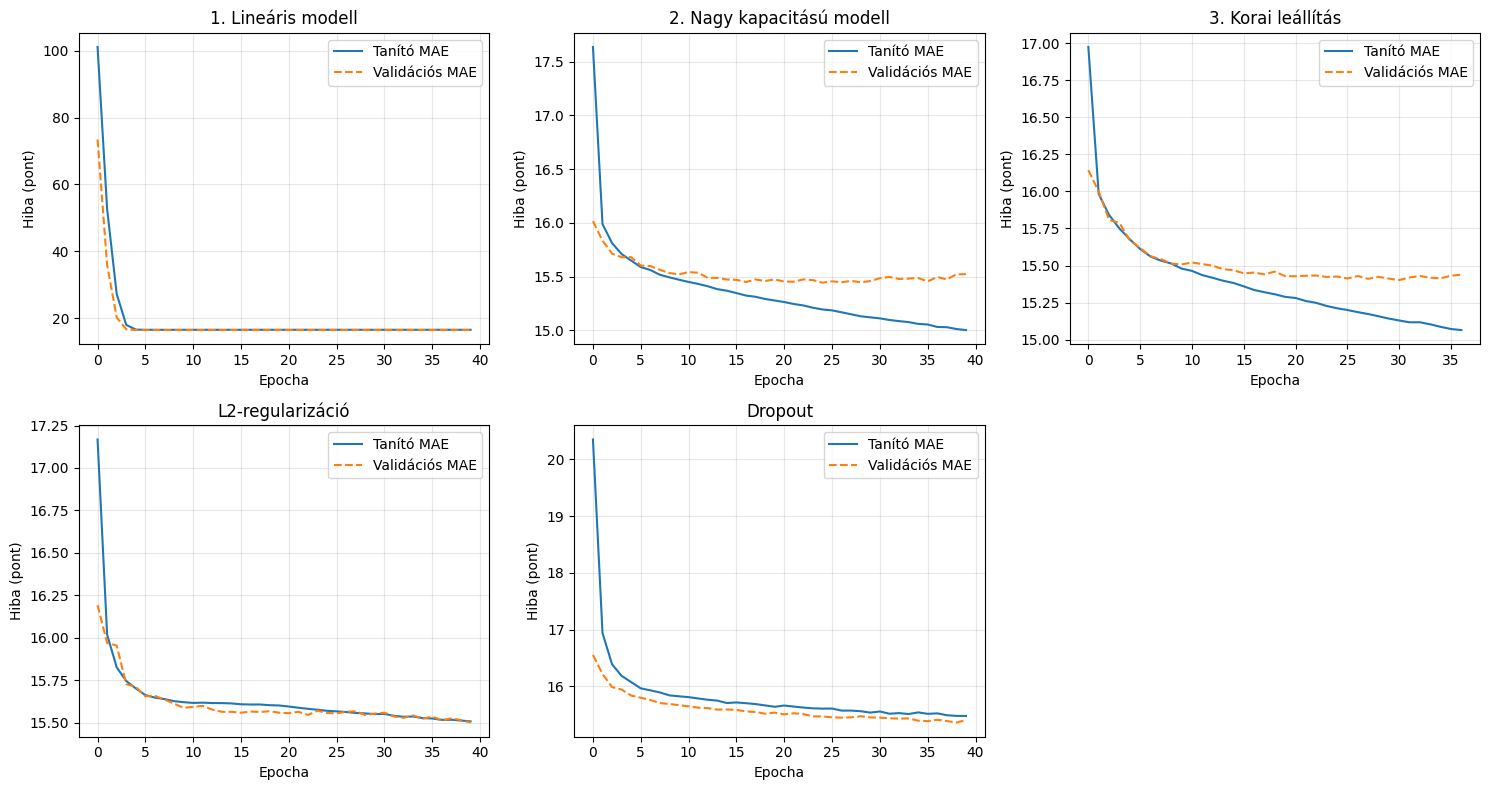

In [ ]:
def plot_history(hist, title):
    train_mae = np.array(hist.history["mae"]) * 100
    val_mae = np.array(hist.history["val_mae"]) * 100

    plt.plot(train_mae, label="Tanító MAE")
    plt.plot(val_mae, label="Validációs MAE", linestyle="--")
    plt.title(title)
    plt.xlabel("Epocha")
    plt.ylabel("Hiba (pont)")
    plt.legend()
    plt.grid(alpha=0.3)

plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plot_history(lin_hist, "1. Lineáris modell")

plt.subplot(2, 3, 2)
plot_history(large_hist, "2. Nagy kapacitású modell")

plt.subplot(2, 3, 3)
plot_history(early_hist, "3. Korai leállítás")

plt.subplot(2, 3, 4)
plot_history(l2_hist, "L2-regularizáció")

plt.subplot(2, 3, 5)
plot_history(drop_hist, "Dropout")

plt.tight_layout()
plt.show()

### 5.1. Hosszabb tanítás ugyanazzal a dropout-beállítással

Most a dropoutos hálózatot **80 epocháig** tanítjuk. A rétegek és a
dropout 0,2-es aránya változatlan, a tanítási keret lesz hosszabb.

Ez is új modell tanítása, nem a 40 epochás súlyok folytatása.
A `drop80_model` és `drop80_hist` külön változók, ezért a korábbi
`drop_model` és `drop_hist` 40 epochás eredménye megmarad.

**Miért most végezzük ezt a próbát?** A hosszabb tanítás is beállításválasztás.
A hatását a validáción nézzük meg, még a végső teszt előtt. A következő
modell-összehasonlításba mindkét dropout-változat bekerül.

Ez a cella tovább futhat a korábbiaknál. Várd meg a befejezését; a
`verbose=0` miatt itt sem kapunk minden epocháról külön sort.

In [ ]:
drop80_model, drop80_hist = run_experiment([128, 64], dropout_rate=0.2, epochs=80)
print("\nA 80 epochás dropout-modell betanítva!")


A 80 epochás dropout-modell betanítva!


### 5.2. Mit adott a hosszabb tanítás?

A következő ábra a 80 epochás futás története. Hasonlítsd össze az előző
ábracsoport 40 epochás dropout-paneljével.

- Javult-e a validációs hiba a hosszabb futás végére?
- Volt-e olyan későbbi szakasz, ahol a tanítási hiba tovább csökkent,
  de a validáció már nem javult?
- Látszik-e egyértelmű trend, vagy inkább ingadozás figyelhető meg?

A két modell külön indulású futás, ezért a különbséget nem tulajdonítjuk
automatikusan és kizárólag a több epochának. A „több tanítás biztosan jobb”
állítást mindenképpen az eredmények alapján kell felülvizsgálni.

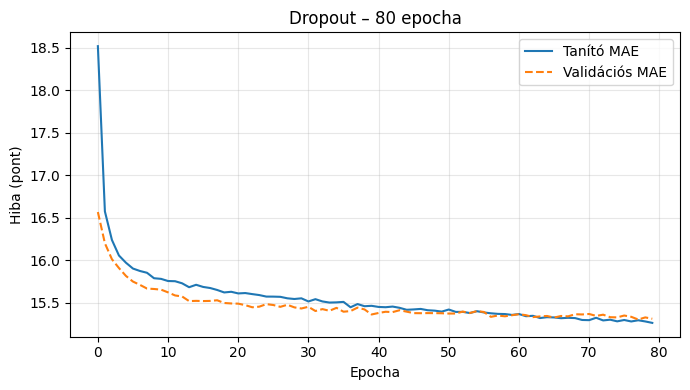

In [ ]:
plt.figure(figsize=(7, 4))
plot_history(drop80_hist, "Dropout – 80 epocha")
plt.tight_layout()
plt.show()

### 6. Modellválasztás a validációs eredmény alapján

A `models` egy szótár: az olvasható modellnévhez a már betanított
modellobjektumot rendeli. A következő ciklus mind a hat tanított modellt
ugyanazon validációs halmazon méri meg.

A `m.evaluate(X_val, y_val, verbose=0)` **nem tanít**, csak értékel.
Ebben a beállításban az első visszaadott érték a teljes `loss`, a második
a külön megadott `mae` metrika. Ezért szerepel a kódban a `[1]` index:
a tiszta becslési hibát választjuk ki. A Python indexelése 0-tól indul.

**Ez L2 esetén különösen fontos:** a teljes loss büntetést is tartalmaz,
de a modellek előrejelzését azonos, büntetés nélküli MAE alapján hasonlítjuk.
A `* 100` ismét visszavált a népszerűségi pontskálára.

A `val_results` név–hiba párokat tárol. A
`min(val_results, key=val_results.get)` annak a modellnek a nevét választja,
amelyhez a legkisebb validációs MAE tartozik. Teljesen azonos tárolt értéknél
a szótárban előbb szereplő modell marad a választás.

A korai leállításos modellnél a visszaállított állapotot értékeljük;
a többi modellnél az utolsó epocha súlyait. Így az egyes tanítási
megoldások ténylegesen megtartott modelljét hasonlítjuk.

**A mediánbecslés szerepe:** a kód a hat tanított modell közül választ,
a medián nem szerepel ebben a szótárban. A kiválasztott modell validációs
MAE-jét külön vesd össze a korábban kiírt mediánhibával is. Ha annál rosszabb,
ne állítsd, hogy a hálózat jobb az egyszerű viszonyítási alapnál.

In [ ]:
models = {
    "Lineáris": lin_model,
    "Nagy kapacitású": large_model,
    "Korai leállítás": early_model,
    "L2-regularizáció": l2_model,
    "Dropout (40 epocha)": drop_model,
    "Dropout (80 epocha)": drop80_model
}

print("=== VALIDÁCIÓS EREDMÉNYEK ===")
val_results = {}
for name, m in models.items():
    err = m.evaluate(X_val, y_val, verbose=0)[1] * 100
    val_results[name] = err
    print(f"{name:20s} -> Validációs MAE: {err:.2f} pont")

best_name = min(val_results, key=val_results.get)
print(f"\nA validáció alapján kiválasztott legjobb tanított modell: {best_name}")

=== VALIDÁCIÓS EREDMÉNYEK ===
Lineáris             -> Validációs MAE: 16.51 pont
Nagy kapacitású      -> Validációs MAE: 15.52 pont
Korai leállítás      -> Validációs MAE: 15.40 pont
L2-regularizáció     -> Validációs MAE: 15.50 pont
Dropout (40 epocha)  -> Validációs MAE: 15.41 pont
Dropout (80 epocha)  -> Validációs MAE: 15.31 pont

A validáció alapján kiválasztott legjobb tanított modell: Dropout (80 epocha)


### 6.1. Állj meg egy pillanatra a teszt előtt!

A döntéshez eddig a validációs eredményeket használtuk. A következő cella
futtatása előtt válaszold meg:

1. Melyik tanított modellnek lett a legkisebb validációs MAE-je?
2. Jobb-e ez a mediánbecslés validációs hibájánál?
3. Nagy vagy kicsi a különbség a legközelebbi másik modellhez képest?

Most lezárjuk a modellválasztást. A teszteredmény megtekintése után már
nem próbálunk újabb neuronszámot, epochaszámot vagy regularizációs beállítást
e teszthalmaz alapján. Ellenkező esetben a teszt fokozatosan újabb
validációs halmazzá válna, és elveszne a független ellenőrzés szerepe.

### 7. Egyszeri végső teszt

A `best_model = models[best_name]` a kiválasztott, már betanított modellt
veszi elő a szótárból. Az `evaluate(X_test, y_test, ...)` ugyanannak a
modellnek a hibáját méri meg az eddig értékelésre nem használt tesztmintákon.
Nincs újratanítás, és a tesztadatok alapján nem változnak a súlyok.

**Csak a kiválasztott modellt mérjük, egyszer.** Ez módszertani szabály:
az egyszerű notebook nem tiltja le technikailag a cella újrafuttatását.
Ne futtasd sorban más modellek tesztjét azért, hogy közülük a teszteredmény
alapján válassz.

Ha például 12,4 pont a teszt-MAE, az átlagosan 12,4 népszerűségi pontnyi
abszolút eltérést jelent. Nem jelenti, hogy minden dal becslése ennyivel tér el,
és nem jelenti, hogy a becslések 87,6%-a helyes.

In [ ]:
# VÉGSŐ DÖNTÉS: kizárólag a kiválasztott modellt teszteljük egyszer
best_model = models[best_name]
test_mae = best_model.evaluate(X_test, y_test, verbose=0)[1] * 100
print(f"--> {best_name} VÉGLEGES TESZT MAE: {test_mae:.2f} pont <--")

--> Dropout (80 epocha) VÉGLEGES TESZT MAE: 15.48 pont <--


### 8. Az eredmény értelmezése és az óra lezárása

A validációs és teszthiba eltérhet, mert különböző mintákon mértük őket.
A teszt egy adott adatfelosztásra és feladatra ad eredményt. A népszerűséget
a kilenc zenei tulajdonságon kívül sok más tényező is befolyásolhatja,
ezért nem várunk szükségszerűen közel nulla hibát.

**A legfontosabb tanulságok:**

- A bemenet és a cél külön szerepet tölt be: a `popularity` nem bemeneti jellemző.
- A standardizáló a tanítóadatokból tanul, a többi halmazra ugyanazt az átalakítást alkalmazza.
- A hálózat kapacitásának növelése és a hosszabb tanítás lehetőség, nem javulási garancia.
- A korai leállítás a megtartott állapotról is dönt.
- L2 mellett a teljes loss és a becslési MAE különböző mennyiség.
- A dropout tanítási és kiértékelési módban eltérően működik.
- A modellválasztás a validációhoz, az egyszeri végső mérés a teszthez tartozik.

#### Rövid önellenőrzés

1. Mit jelent itt az `X_train.shape[1]`?
2. Miért nem teszi osztályozássá a feladatot az y 100-zal osztása?
3. Miért csak a tanítóhalmazon hívjuk a `fit_transform` műveletet?
4. Mit jelent a `run_experiment([])` üres listája?
5. Miért kell L2 mellett külön is figyelnünk a MAE-t?
6. Mi történik a dropouttal validáció és teszt közben?
7. Miért nem feltétlenül az utolsó epocha súlyait tartja meg a korai leállítás?
8. Miért nem hangolunk tovább a teszteredmény alapján?

<details>
<summary>Rövid válaszok – gondolkodás után nyisd le</summary>
<ol>
<li>A mintánkénti jellemzőszámot, ebben a példában 9-et.</li>
<li>Folytonos pontszámot becslünk, csak más skálán; nem osztályvalószínűséget.</li>
<li>Így a validáció és a teszt nem befolyásolja az előfeldolgozás megtanult paramétereit.</li>
<li>Nincs rejtett réteg; közvetlenül egy lineáris kimeneti réteg készül.</li>
<li>A loss a súlybüntetést is tartalmazza, a MAE a tiszta becslési hibát méri.</li>
<li>Nem nulláz aktivációkat, és nincs külön kiértékelési skálázás.</li>
<li>A restore_best_weights=True a legjobb megfigyelt validációs állapotot állítja vissza.</li>
<li>A teszt akkor ad független lezáró mérést, ha nem használjuk további modellválasztásra.</li>
</ol>
</details>

**A 4. gyakorlat végére értél.** A teszt után ebben a notebookban nincs újabb tanítási feladat.